In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from astropy.time import Time
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
np.random.seed(42)

In [30]:
injections_all = pd.read_csv('injections.dat', delimiter='\t')
bns_index = np.logical_and(injections_all['mass1'] < 2.0606, injections_all['mass2'] < 2.0606)
injections = injections_all[bns_index].copy()
# allsky = pd.read_csv('allsky_cleaned.csv')
injections.head()

,simulation_id,longitude,latitude,inclination,distance,mass1,mass2,spin1z,spin2z
0,0,1.775553,-0.755829,0.679470,408.623900,1.586891,1.541205,-0.008728,-0.451589
1,1,0.623389,-0.809760,2.681881,339.980160,1.858558,1.793734,-0.012189,0.065558
2,2,2.807560,-0.053046,0.574456,384.828880,1.692769,1.636642,-0.079513,-0.205606
3,3,0.111012,-0.326715,0.491584,389.414390,1.877971,1.623694,-0.165918,0.247047
4,4,0.901710,0.344590,0.219969,99.830336,1.207587,1.079114,0.275840,0.397851


Using SFHo EOS to calculate compactness C. The grid data is saved at 'eos.mr'.

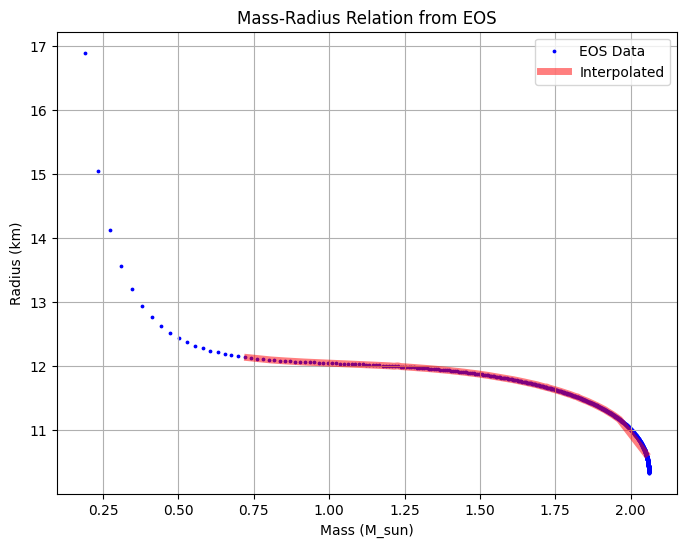

In [31]:
eos = pd.read_csv('eos.mr', names=['radius', 'mass'], sep='\s+', skiprows=1)

mass = eos['mass'].values
radius = eos['radius'].values
f = interp1d(mass, radius, kind='cubic', fill_value="extrapolate")
mass1 = np.sort(np.random.normal(1.4, 0.2, size=1000))
radius1 = f(mass1)

plt.figure(figsize=(8,6))
plt.scatter(mass, radius, label='EOS Data', color='b',s=3)
plt.plot(mass1, radius1, label='Interpolated', color='r', alpha=0.5, linewidth=5)
plt.xlabel('Mass (M_sun)')
plt.ylabel('Radius (km)')
plt.title('Mass-Radius Relation from EOS')
plt.legend()
plt.grid()

In [32]:
def compute_radius(mass, eos_file):
    eos = pd.read_csv(eos_file, names=['radius', 'mass'], sep='\s+', skiprows=1)
    mass_eos = eos['mass'].values
    radius_eos = eos['radius'].values
    f = interp1d(mass_eos, radius_eos, kind='cubic', fill_value="extrapolate")
    radius = f(mass)
    return radius

In [33]:
mass1 = injections['mass1'].values
mass2 = injections['mass2'].values

radius1 = np.around(f(mass1),decimals=6)
radius2 = np.around(f(mass2),decimals=6)
injections.loc[:, 'radius1'] = radius1
injections.loc[:, 'radius2'] = radius2

In [34]:
def compute_compactness(mass, radius):

    G = 6.67430e-11  # m^3 kg^-1 s^-2
    c = 299792458    # m/s
    Ms = 1.98855e30  # kg
    C = (G * mass * Ms) / (c**2 * radius * 1000)  # radius in km to m
    return np.around(C, decimals=5)

compactness1 = compute_compactness(mass1, radius1)
compactness2 = compute_compactness(mass2, radius2)
injections['compactness1'] = compactness1
injections['compactness2'] = compactness2

## Compute ejecta mass
In Bulla KN model, ejecta has two components: dynamical ejecta and wind ejecta. We can calculate them with gravitational wave parameters. 

Reference: *Predictions for electromagnetic counterparts to Neutron Star mergers discovered during LIGO-Virgo-KAGRA observing runs 4 and 5*

For dynamical ejecta mass, 
$log_{10}(m^{dyn fit}_{ej})=[a\frac{(1-2C_1)M_1}{C_1}+bM_2(\frac{M_1}{M_2})^n+\frac{d}{2}]+[1\leftrightarrow 2]$
, where $a=-0.0719, b=0.2116, d=-2.42, n=-2.905$;

$C=\frac{GW}{c^2R}$

In [35]:
def dynamical_ejecta_mass(m1, m2, c1, c2):
    a = -0.0719
    b = 0.2116
    d = -2.42
    n = -2.905
    
    term1 = (a * (1 - 2 * c1) * m1 / c1) + (b * m2 * (m1 / m2) ** n) + (d / 2)
    term2 = (a * (1 - 2 * c2) * m2 / c2) + (b * m1 * (m2 / m1) ** n) + (d / 2)
    
    log_mej_dyn = term1 + term2
    mej_dyn = 10 ** log_mej_dyn
    
    return mej_dyn

In [36]:
mej_dyn_fit = dynamical_ejecta_mass(mass1, mass2, compactness1, compactness2)
mej_dyn = np.minimum(0.09, mej_dyn_fit)
injections['mej_dyn'] = np.around(mej_dyn, decimals=6)
print("Dynamical Ejecta Mass(M_sun):")
print(mej_dyn)

Dynamical Ejecta Mass(M_sun):
[0.00349943 0.00580478 0.00422605 ... 0.0055939  0.01403486 0.00389628]


For wind ejcta mass:

$m_{ej}^{wind}=\zeta m_{disc}$, $\zeta$ is sampled uniformly from $[0.1,0.4]$;

$log_{10}(m_{disk})=max(-3,a(1+b \cdot \tanh[\frac{c-(M_1+M_2)/M_{thr}}{d}]))$,where $a=-31.335,b=-0.9760,c=1.0474,d=0.05957$;

$M_{thr} = (2.38-3.606\frac{M_{TOV}}{R_{1.6M_{\odot}}})M_{TOV}$,$M_{TOV}=2.05M_{\odot}$

In [37]:
def compute_wind_ejecta_mass(m1, m2, Mthr, zeta):
    a = -31.335
    b = -0.9760
    c = 1.0474
    d = 0.05957
    
    Mtot = m1 + m2
    log_mdisk = np.maximum(-3, a * (1 + b * np.tanh((c - Mtot / Mthr) / d)))
    mdisk = 10 ** log_mdisk
    
    mej_wind = zeta * mdisk
    return mej_wind

In [38]:
Rthr = f(1.6)
MTOV = 2.05  # in solar masses
Mthr = (2.38 - 3.606 * (MTOV / Rthr)) * MTOV
print("Radius at 1.6M_sun R_1.6(km):", Rthr)
print("Threshold Mass M_thr(M_sun):", Mthr)

Radius at 1.6M_sun R_1.6(km): 11.790587325737482
Threshold Mass M_thr(M_sun): 3.593719243296717


In [39]:
zeta = np.random.uniform(0.1, 0.4, size=len(mass1))
mej_wind = compute_wind_ejecta_mass(mass1, mass2, Mthr, zeta)
injections['mej_wind'] = np.around(mej_wind, decimals=6)
print("Wind Ejecta Mass(M_sun):")
print(mej_wind)

Wind Ejecta Mass(M_sun):
[0.01437391 0.00025702 0.00587508 ... 0.00021639 0.01973645 0.02770245]


If $m_1+m_2 \geq M_{thr}$, set both dynamical and wind ejcta to zero.

In [40]:
index = np.where((mass1 + mass2) >= Mthr)[0]
print("Indices with total mass >= M_thr:", index)
injections.iloc[index, injections.columns.get_loc('mej_dyn')] = 0.0
injections.iloc[index, injections.columns.get_loc('mej_wind')] = 0.0

Indices with total mass >= M_thr: [    1    12    13 ... 22933 22934 22938]


Save new injections parameters.

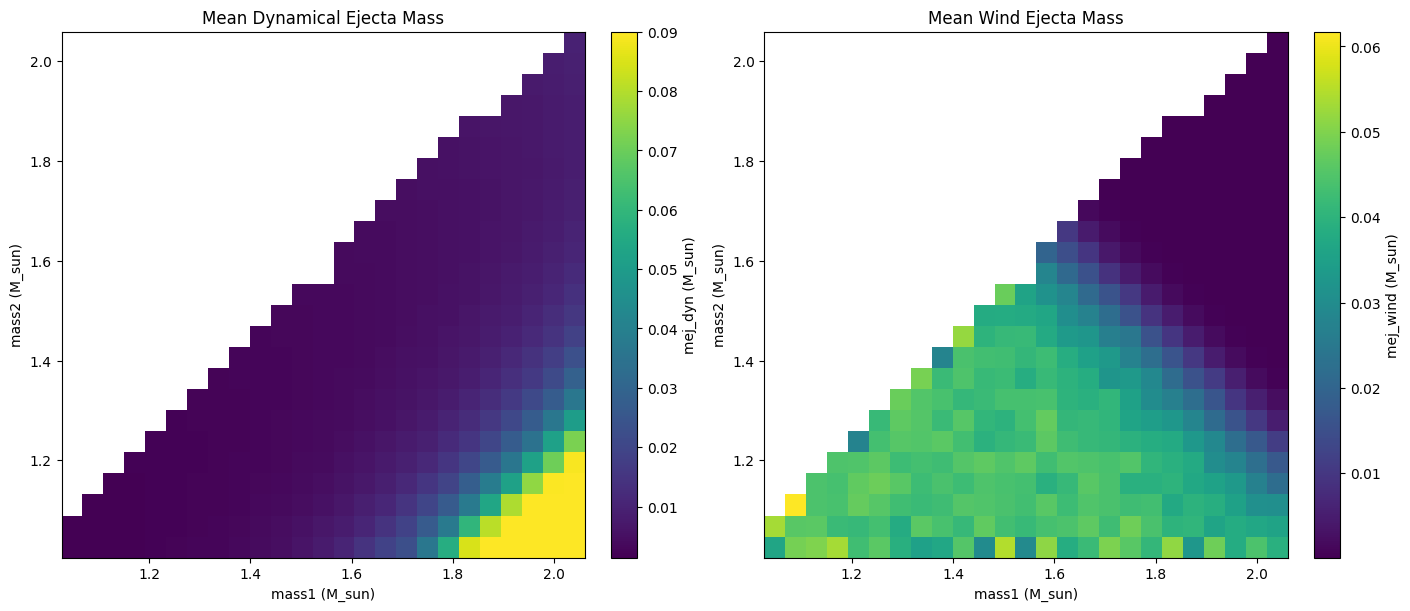

In [41]:
# Heatmaps of ejecta masses vs (mass1, mass2)
bins = 25

# 2D mean for dynamical ejecta
H_sum_dyn, xedges, yedges = np.histogram2d(mass1, mass2, bins=bins, weights=mej_dyn)
H_count, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges])
H_mean_dyn = H_sum_dyn / np.where(H_count == 0, np.nan, H_count)

# 2D mean for wind ejecta
H_sum_wind, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges], weights=mej_wind)
H_mean_wind = H_sum_wind / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean_dyn.T, cmap='viridis', shading='auto')
axs[0].set_xlabel('mass1 (M_sun)')
axs[0].set_ylabel('mass2 (M_sun)')
axs[0].set_title('Mean Dynamical Ejecta Mass')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('mej_dyn (M_sun)')

im1 = axs[1].pcolormesh(xedges, yedges, H_mean_wind.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('mass1 (M_sun)')
axs[1].set_ylabel('mass2 (M_sun)')
axs[1].set_title('Mean Wind Ejecta Mass')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('mej_wind (M_sun)')

plt.show()

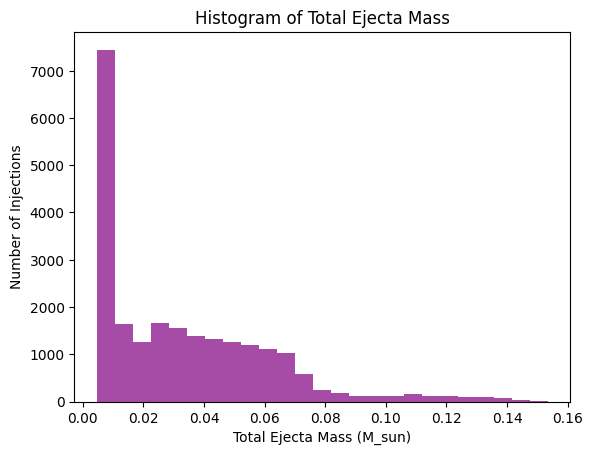

In [42]:
# total mass of ejecta
mej_total = mej_dyn + mej_wind
injections.loc[:, "mej_total"] = np.around(mej_total, decimals=6)

plt.hist(injections['mej_total'], bins=25, color='purple', alpha=0.7)
plt.xlabel('Total Ejecta Mass (M_sun)')
plt.ylabel('Number of Injections')
plt.title('Histogram of Total Ejecta Mass')
plt.show()

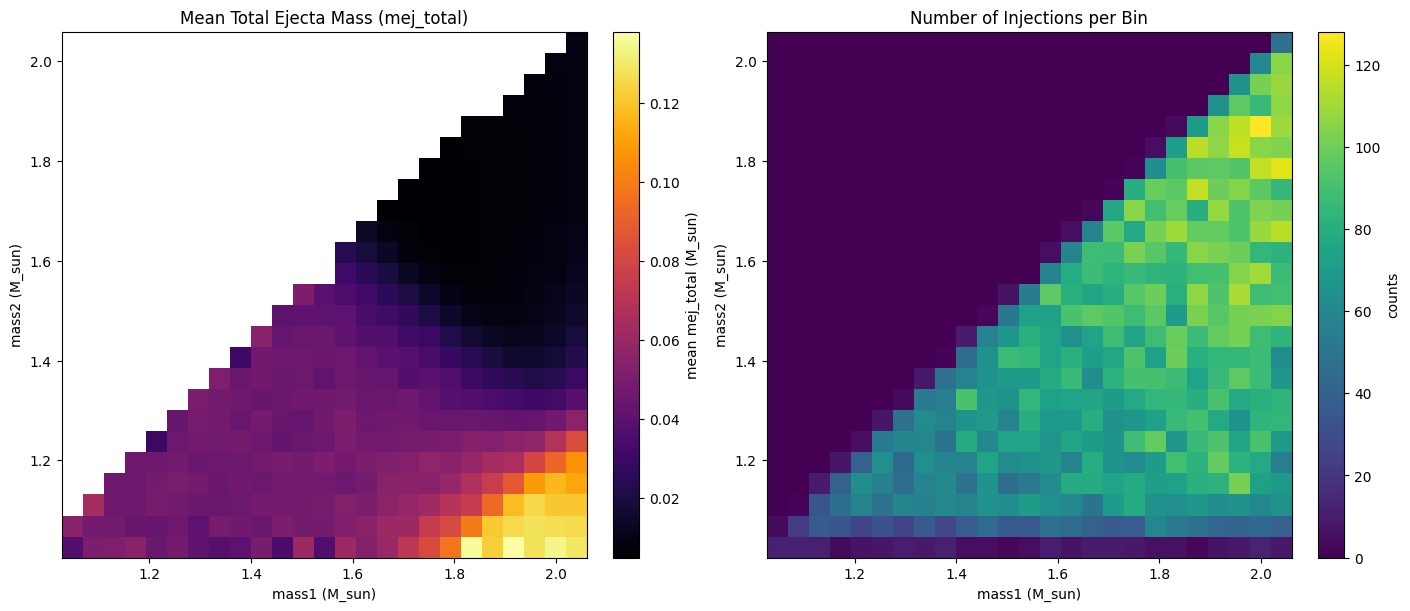

In [43]:
# 2D mean (and count) of total ejecta mass vs (mass1, mass2)
bins = 25

H_sum, xedges, yedges = np.histogram2d(mass1, mass2, bins=bins, weights=mej_total)
H_count, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges])
H_mean = H_sum / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean.T, cmap='inferno', shading='auto')
axs[0].set_xlabel('mass1 (M_sun)')
axs[0].set_ylabel('mass2 (M_sun)')
axs[0].set_title('Mean Total Ejecta Mass (mej_total)')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('mean mej_total (M_sun)')

# show counts in the other panel
im1 = axs[1].pcolormesh(xedges, yedges, H_count.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('mass1 (M_sun)')
axs[1].set_ylabel('mass2 (M_sun)')
axs[1].set_title('Number of Injections per Bin')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('counts')

plt.show()

Add half-opening angle($\Phi$) and observing angle($Cos\Theta$).

$\Phi \in U(15^o, 75^o)$, $\Theta=min(\iota, \pi-\iota)$ 

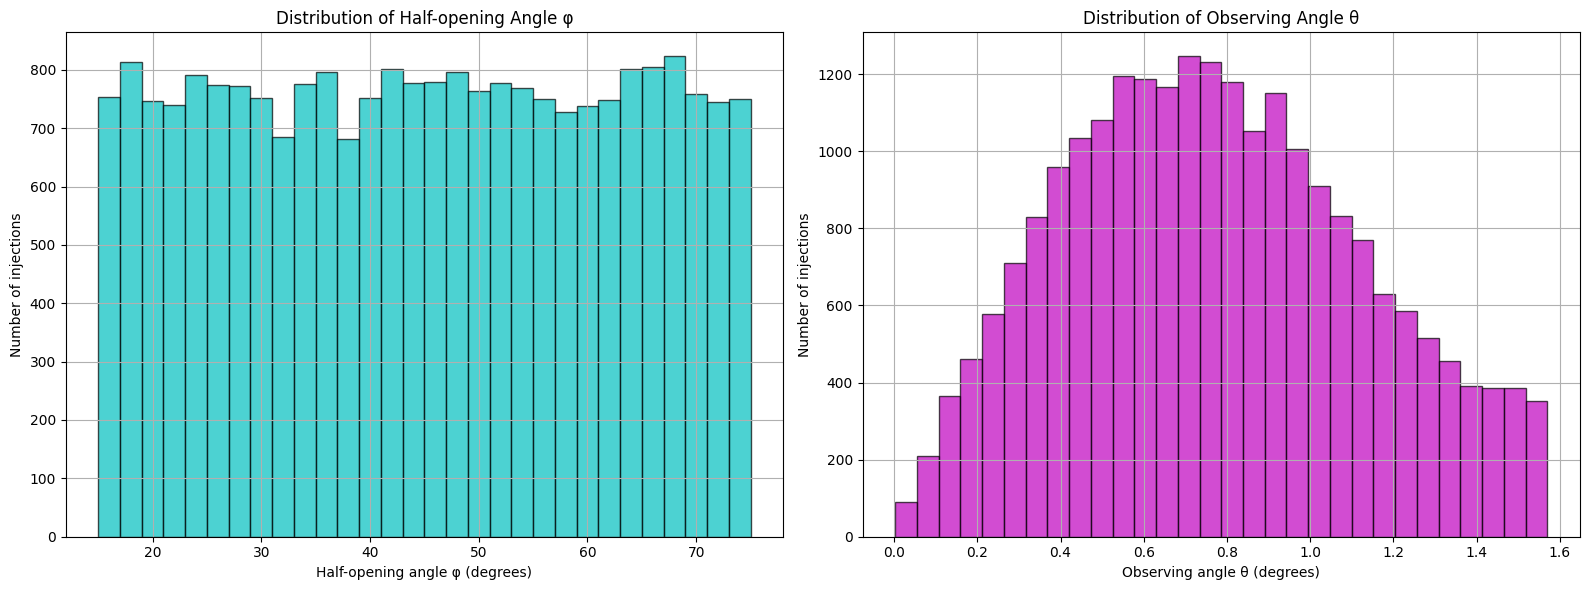

In [44]:
# half-opening angle phi
phi = np.random.uniform(15, 75, size=len(mass1))

# observing angle theta
inclination = injections['inclination'].values
theta = np.where(inclination <= np.pi/2, inclination, (np.pi - inclination))

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.hist(phi, bins=30, color='c', edgecolor='k', alpha=0.7)
plt.xlabel('Half-opening angle φ (degrees)')
plt.ylabel('Number of injections')
plt.title('Distribution of Half-opening Angle φ')
plt.grid()
plt.subplot(1,2,2)
plt.hist(theta, bins=30, color='m', edgecolor='k', alpha=0.7)
plt.xlabel('Observing angle θ (degrees)')
plt.ylabel('Number of injections')
plt.title('Distribution of Observing Angle θ')
plt.grid()
plt.tight_layout()

injections.loc[:, 'phi'] = np.around(phi, decimals=6)
injections.loc[:, 'costheta'] = np.around(np.cos(theta), decimals=6)

### Add distance and uncertainty in skymap.

In [45]:
ra = np.rad2deg(injections['longitude'].values)
dec = np.rad2deg(injections['latitude'].values)

injections.loc[:, 'ra'] = np.around(ra, decimals=6)
injections.loc[:, 'dec'] = np.around(dec, decimals=6)

In [49]:
# get distance info from skymap file
from astropy.io import fits
from tqdm import tqdm

skymap_path = "/fred/oz016/bgao_kn/observing-scenarios-simulations/runs/O5a/bns_training_seed42/allsky/"
# Read simulation_id from injections to match skymap files
simulation_ids = injections['simulation_id'].values

distmean_list = []
diststd_list = []

for sim_id in tqdm(simulation_ids, desc="Extracting distance info from skymaps"):
    skymap_file = f"{skymap_path}{sim_id}.fits"
    try:
        with fits.open(skymap_file) as hdul:
            header = hdul[1].header
            distmean_list.append(header.get('DISTMEAN', np.nan))
            diststd_list.append(header.get('DISTSTD', np.nan))
    except Exception as e:
        distmean_list.append(np.nan)
        diststd_list.append(np.nan)

allsky = pd.DataFrame({'distmean': distmean_list, 'diststd': diststd_list})

Extracting distance info from skymaps: 100%|██████████| 22941/22941 [11:31<00:00, 33.20it/s] 


In [51]:
allsky.to_csv("allsky.csv", index=False)

In [52]:
distmean = allsky['distmean'].values
diststd = allsky['diststd'].values

injections['distmean'] = np.around(distmean, decimals=6)
injections['diststd'] = np.around(diststd, decimals=6)

In [53]:
# add GPS time and mjd time columns
mjd_min = 61000.0
mjd_max = 64500.0
mjd_times = np.random.uniform(mjd_min, mjd_max, size=len(injections))
gps_times = Time(mjd_times, format='mjd').gps

injections['mjd_time'] = np.around(mjd_times, decimals=4)
injections['gps_time'] = np.around(gps_times, decimals=2)

/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 15492 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [54]:
# re-order columns
cols = list(injections.columns)
cols.insert(1, cols.pop(cols.index('mjd_time')))
cols.insert(2, cols.pop(cols.index('gps_time')))
cols.insert(5, cols.pop(cols.index('ra')))
cols.insert(6, cols.pop(cols.index('dec')))

injections = injections[cols]
print(injections.columns)

Index(['simulation_id', 'mjd_time', 'gps_time', 'longitude', 'latitude', 'ra',
       'dec', 'inclination', 'distance', 'mass1', 'mass2', 'spin1z', 'spin2z',
       'radius1', 'radius2', 'compactness1', 'compactness2', 'mej_dyn',
       'mej_wind', 'mej_total', 'phi', 'costheta', 'distmean', 'diststd'],
      dtype='object')


In [55]:
injections

,simulation_id,mjd_time,gps_time,longitude,latitude,ra,dec,inclination,distance,mass1,...,radius2,compactness1,compactness2,mej_dyn,mej_wind,mej_total,phi,costheta,distmean,diststd
0,0,61918.6860,1.527093e+09,1.775553,-0.755829,101.731670,-43.305802,0.679470,408.623900,1.586891,...,11.837381,0.19857,0.19227,0.003499,0.014374,0.017873,63.489759,0.777906,338.827222,113.404008
1,1,62991.0620,1.619746e+09,0.623389,-0.809760,35.717579,-46.395824,2.681881,339.980160,1.858558,...,11.558667,0.23991,0.22917,0.000000,0.000000,0.006062,74.906399,0.896181,283.550082,65.346507
2,2,61417.4549,1.483787e+09,2.807560,-0.053046,160.861327,-3.039317,0.574456,384.828880,1.692769,...,11.755901,0.21371,0.20559,0.004226,0.005875,0.010101,23.028581,0.839488,510.911771,154.289575
3,3,63108.1934,1.629866e+09,0.111012,-0.326715,6.360525,-18.719419,0.491584,389.414390,1.877971,...,11.768747,0.24330,0.20374,0.006125,0.000171,0.006296,53.253791,0.881586,461.785941,152.162605
4,4,61604.2657,1.499927e+09,0.901710,0.344590,51.664185,19.743537,0.219969,99.830336,1.207587,...,12.025219,0.14867,0.13252,0.001813,0.065702,0.067514,70.518556,0.975904,81.284861,18.071208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28129,28129,62553.3049,1.581924e+09,5.193737,0.726264,297.579221,41.611854,2.180040,480.738930,1.956013,...,11.984410,0.25825,0.15313,0.033748,0.009529,0.043277,37.412478,0.572247,475.799659,149.063397
28130,28130,61067.6761,1.453566e+09,1.514465,-0.844040,86.772447,-48.359953,0.870882,468.376350,1.324171,...,11.973073,0.16354,0.15773,0.002207,0.068324,0.070531,64.047785,0.644152,569.098489,175.710456
28131,28131,63274.3747,1.644224e+09,5.153384,0.510227,295.267153,29.233864,0.381346,164.886500,1.848856,...,11.628807,0.23826,0.22180,0.000000,0.000000,0.005810,70.646168,0.928164,135.058589,31.341512
28132,28132,61581.6221,1.497971e+09,3.937431,0.151759,225.598201,8.695165,1.595317,273.720520,1.819977,...,11.988668,0.23344,0.15215,0.014035,0.019736,0.033771,33.433067,0.024518,591.805224,176.010261


Add redshift and mass in detector frame 

In [56]:
# injections = pd.read_csv('injections_final.csv')
redshift = np.array([z_at_value(cosmo.luminosity_distance, d * u.Mpc) for d in injections['distance'].values])
injections['redshift'] = np.around(redshift, decimals=7)
mass1_detector = injections['mass1'] * (1 + injections['redshift'])
mass2_detector = injections['mass2'] * (1 + injections['redshift'])
injections['mass1_detector'] = np.around(mass1_detector, decimals=7)
injections['mass2_detector'] = np.around(mass2_detector, decimals=7)
injections

,simulation_id,mjd_time,gps_time,longitude,latitude,ra,dec,inclination,distance,mass1,...,mej_dyn,mej_wind,mej_total,phi,costheta,distmean,diststd,redshift,mass1_detector,mass2_detector
0,0,61918.6860,1.527093e+09,1.775553,-0.755829,101.731670,-43.305802,0.679470,408.623900,1.586891,...,0.003499,0.014374,0.017873,63.489759,0.777906,338.827222,113.404008,0.086648,1.724391,1.674747
1,1,62991.0620,1.619746e+09,0.623389,-0.809760,35.717579,-46.395824,2.681881,339.980160,1.858558,...,0.000000,0.000000,0.006062,74.906399,0.896181,283.550082,65.346507,0.072777,1.993819,1.924276
2,2,61417.4549,1.483787e+09,2.807560,-0.053046,160.861327,-3.039317,0.574456,384.828880,1.692769,...,0.004226,0.005875,0.010101,23.028581,0.839488,510.911771,154.289575,0.081867,1.831350,1.770628
3,3,63108.1934,1.629866e+09,0.111012,-0.326715,6.360525,-18.719419,0.491584,389.414390,1.877971,...,0.006125,0.000171,0.006296,53.253791,0.881586,461.785941,152.162605,0.082790,2.033448,1.758120
4,4,61604.2657,1.499927e+09,0.901710,0.344590,51.664185,19.743537,0.219969,99.830336,1.207587,...,0.001813,0.065702,0.067514,70.518556,0.975904,81.284861,18.071208,0.022157,1.234344,1.103025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28129,28129,62553.3049,1.581924e+09,5.193737,0.726264,297.579221,41.611854,2.180040,480.738930,1.956013,...,0.033748,0.009529,0.043277,37.412478,0.572247,475.799659,149.063397,0.100969,2.153509,1.368168
28130,28130,61067.6761,1.453566e+09,1.514465,-0.844040,86.772447,-48.359953,0.870882,468.376350,1.324171,...,0.002207,0.068324,0.070531,64.047785,0.644152,569.098489,175.710456,0.098531,1.454643,1.404835
28131,28131,63274.3747,1.644224e+09,5.153384,0.510227,295.267153,29.233864,0.381346,164.886500,1.848856,...,0.000000,0.000000,0.005810,70.646168,0.928164,135.058589,31.341512,0.036221,1.915823,1.809859
28132,28132,61581.6221,1.497971e+09,3.937431,0.151759,225.598201,8.695165,1.595317,273.720520,1.819977,...,0.014035,0.019736,0.033771,33.433067,0.024518,591.805224,176.010261,0.059151,1.927631,1.308256


In [57]:
injections.to_csv('injections_final.csv', index=False)